In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


protocol_times=[10,20,100,200,500,800,1000,2000,3000,5000]
protocol_times_fine=[100,500,800,1000,2000,3000,5000]
opt_dict={}
opt_dict_new={}
opt_dict_fine={}
long_dict={}



In [2]:
# serialization of process tensor (optional)
import dill

for t_prot in protocol_times:
# processtensor_simplemodel
    file_name1='results/zero_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot)
    with open(file_name1,'rb') as f:
        opt_dict[t_prot]=dill.load(f)


long_times=[100,500,800,1000,2000]

for t_prot in long_times:
    file_name2='results/optimised_longer/dt=0.2ps_eps=-8.0_tcut=30/{0}ps'.format(t_prot)
    with open(file_name2,'rb') as f:
        long_dict[t_prot]= dill.load(f)

for t_prot in protocol_times_fine:
# processtensor_simplemodel
    file_name1='results/zero_control_0.2ps_8/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot)
    with open(file_name1,'rb') as f:
        opt_dict_fine[t_prot]=dill.load(f)


FileNotFoundError: [Errno 2] No such file or directory: 'results/optimised_longer/dt=0.2ps_eps=-8.0_tcut=30/100ps'

In [8]:
t,sx=long_dict[100]['dynamics'].expectations(op.sigma("x"))
t[-1]

120.0

In [ ]:
t,sx=long_dict.expectations(op.sigma('x'),real=True)
plt.plot(t,sx)
t,sx=opt_dict[10]['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
plt.plot(t,sx,'ro')
plt.show()
print(opt_dict[10]['parameters'])

In [ ]:
fine_times=[opt_dict_fine[t_prot]['opttime'][0] for t_prot in protocol_times_fine]
coarse_times=[opt_dict[t_prot]['opttime'][0] for t_prot in protocol_times]

fine_its =[ np.shape(opt_dict_fine[t_prot]['log'])[0] for t_prot in protocol_times_fine]
coarse_its =[ np.shape(opt_dict[t_prot]['log'])[0] for t_prot in protocol_times]

In [12]:
for key in opt_dict_new: 
    print(key)

In [ ]:
# plotting final heat values
heat_coarse=[]
for t_prot in opt_dict:
    try:
        heat_coarse.append(opt_dict[t_prot]['result'].fun)
    except:
        heat_coarse.append(opt_dict[t_prot].fun)

heat_fine=[]
for t_prot in opt_dict_fine:
    heat_fine.append(opt_dict_fine[t_prot]['result'].fun)

    

heat_long=[]
for t_prot in long_times:
    heat_long.append(long_dict[t_prot]['dynamicscf'].states.trace(axis1=1,axis2=2)[-1].imag/0.01)

fig,[ax1,ax2,ax3]=plt.subplots(1,3,figsize=(18,6))
u=0.01
'''
heat_t=opt_dict_new['heatanddynamics']['heat'].states.trace(axis1=1,axis2=2).imag/u
ax1.plot(1000,heat_t[-1], 'bo',label='optimised coarse,calculated fine')
'''
ax1.plot(protocol_times,heat_coarse,'ro',label='optimised coarse (dt=0.25ps,eps=1e-7)')
ax1.plot(protocol_times_fine,heat_fine,'go',label='optimised fine (dt=0.2ps,eps=1e-8)')

ax1.plot(long_times,heat_long,'bo',label='optimised coarse, calculated fine (dt=0.2ps,eps=1e-7, tcut=30ps)')
ax1.set_ylabel('heat (sys->bath) /s')
ax1.set_xlabel('protocol time /ps')

ax2.plot(protocol_times[:7],coarse_times[:7],label='coarse',c='r')
ax2.plot(protocol_times_fine,fine_times,label='fine',c='g')
ax2.set_ylabel('run time /s')
ax2.set_xlabel('protocol time /ps')
ax1.legend()
ax2.legend()

ax3.plot(protocol_times[:7],coarse_its[:7],label='coarse',c='r')
ax3.plot(protocol_times_fine,fine_its,label='fine',c='g')
ax3.set_ylabel('num iteration')
ax3.set_xlabel('protocol time /ps')
ax1.legend()
ax2.legend()
ax3.legend()
plt.legend()
plt.show()

In [ ]:
print(len(heat_fine[4]))

In [ ]:
fig=plt.figure(figsize=(12,8))
gs=fig.add_gridspec(3,hspace=0.2)
axs=gs.subplots(sharex=True)
t_prot=100
t,sx=opt_dict_fine[t_prot]['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
t,sy=opt_dict_fine[t_prot]['fidelitygrad']['dynamics'].expectations(op.sigma('y'),real=True)
t,sz=opt_dict_fine[t_prot]['fidelitygrad']['dynamics'].expectations(op.sigma('z'),real=True)
heat_t=opt_dict_fine[t_prot]['log'][-1]['full heats']
opt_control=opt_dict_fine[t_prot]['result'].x

print(len(sx))

axs[0].plot(t,sx)
#axs[0].plot(t,sy)
#axs[0].plot(t,sz)
axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')


axs[1].plot(t,heat_t)
axs[1].set_ylabel(r'$\langle Q \rangle$')

axs[2].plot(t[:-1],opt_control)
axs[2].set_ylabel(r'$\langle h_x \rangle$')

axs[2].minorticks_on()
#axs[2].set_xticks(np.arange(0,10,step=0.25))

Text(0, 0.5, '$\\langle Q \\rangle$')

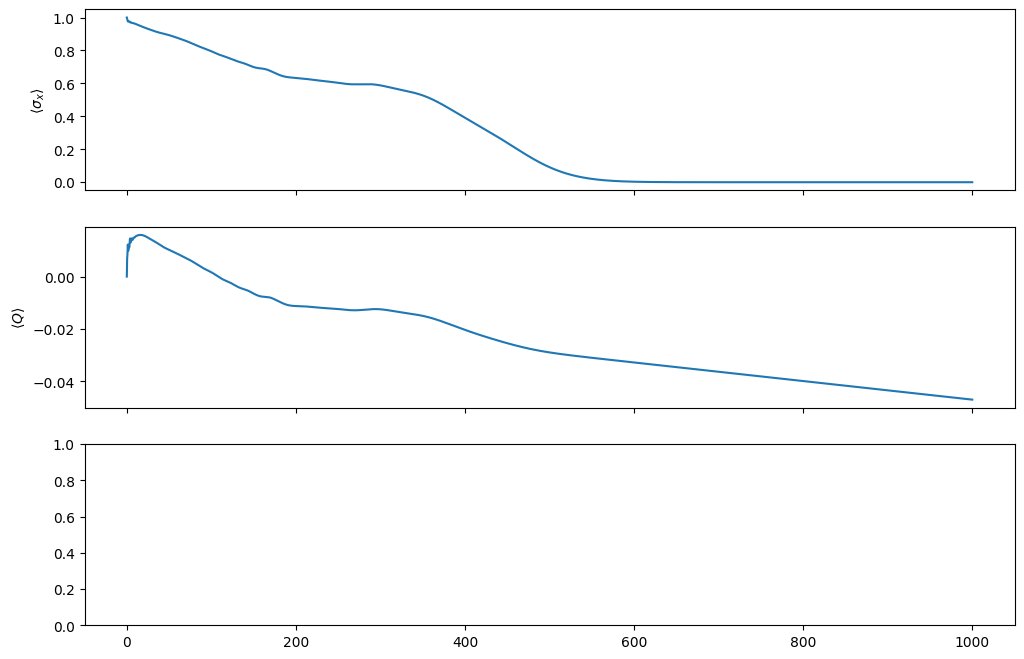

In [101]:
fig=plt.figure(figsize=(12,8))
gs=fig.add_gridspec(3,hspace=0.2)
axs=gs.subplots(sharex=True)
t_prot=1000
u=0.01
t,sx=opt_dict_new['heatanddynamics']['dynamics'].expectations(op.sigma('x'),real=True)
t,sy=opt_dict_new['heatanddynamics']['dynamics'].expectations(op.sigma('y'),real=True)
t,sz=opt_dict_new['heatanddynamics']['dynamics'].expectations(op.sigma('z'),real=True)
heat_t=opt_dict_new['heatanddynamics']['heat'].states.trace(axis1=1,axis2=2).imag/u
opt_control=opt_dict_new['result'].x

axs[0].plot(t,sx)
#axs[0].plot(t,sy)
#axs[0].plot(t,sz)
axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')


axs[1].plot(t,heat_t)
axs[1].set_ylabel(r'$\langle Q \rangle$')
#axs[2].set_xticks(np.arange(0,10,step=0.25))

(-1.0, 1.0)

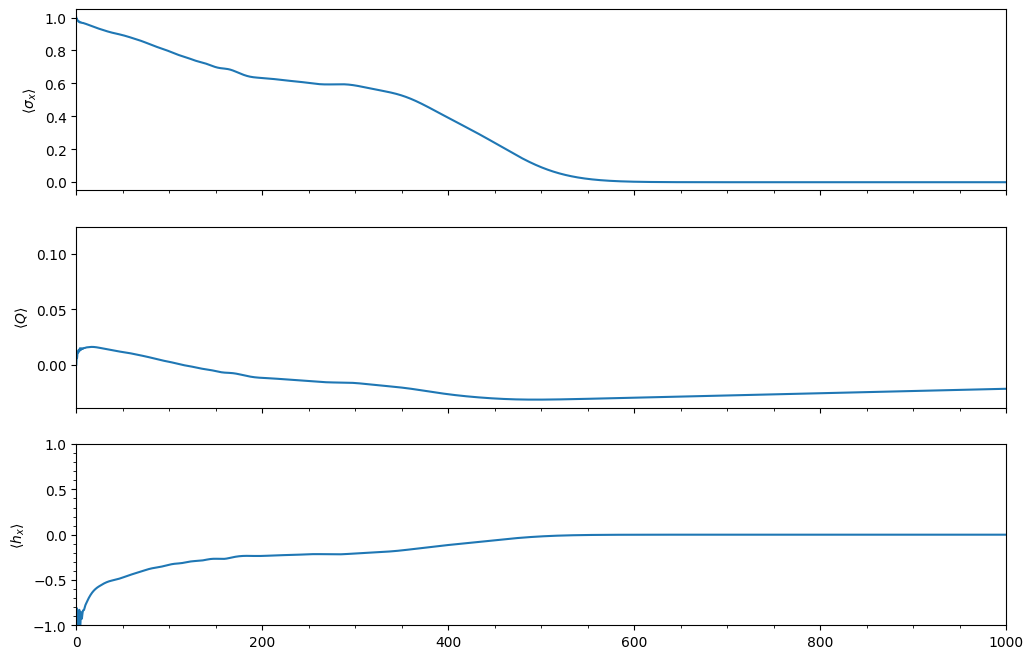

In [45]:
fig=plt.figure(figsize=(12,8))
gs=fig.add_gridspec(3,hspace=0.2)
axs=gs.subplots(sharex=True)
t,sx=opt_dict[8000]['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
heat_t=opt_dict[8000]['log'][-1]['full heats']
opt_control=opt_dict[8000]['result'].x

axs[0].plot(t,sx)
axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')


axs[1].plot(t,heat_t)
axs[1].set_ylabel(r'$\langle Q \rangle$')

axs[2].plot(t[:-1],opt_control)
axs[2].set_ylabel(r'$\langle h_x \rangle$')

axs[2].minorticks_on()
#axs[2].set_xticks(np.arange(0,10,step=0.25))
axs[2].set_xlim(0,1000)
axs[2].set_ylim(-1,1)

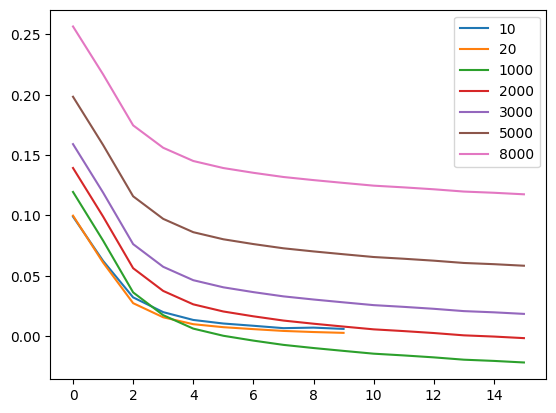

In [16]:
for t_prot in protocol_times:
    num_iterations=np.shape(opt_dict[t_prot]['log'])[0]
    heat_iter=[]
    for i in range(num_iterations):
        heat_iter.append(opt_dict[t_prot]['log'][i]['final heat'])
    plt.plot(range(num_iterations),heat_iter,label=t_prot)

plt.legend()
plt.show()

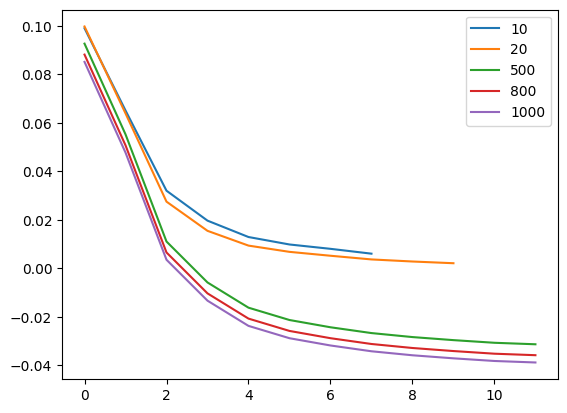

In [54]:
for t_prot in protocol_times_fine:
    num_iterations=np.shape(opt_dict_fine[t_prot]['log'])[0]
    heat_iter=[]
    for i in range(num_iterations):
        heat_iter.append(opt_dict_fine[t_prot]['log'][i]['final heat'])
    plt.plot(range(num_iterations),heat_iter,label=t_prot)

plt.legend()
plt.show()

<span style="color:red"><b><<<<<<< local</b></span>

In [ ]:
# plot bond dimension of process tensors (cf and non cf) as functions of epsrel and tcut 

<span style="color:red"><b>=======</b></span>

<span style="color:red"><b>>>>>>>> remote</b></span>